In [1]:
from pathlib import Path
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt

current_path = Path.cwd()
project_root = current_path if (current_path / "requirements.txt").exists() else current_path.parent
assets_dir = project_root / "assets"
chart_output_path = assets_dir / "basic_chart.png"
previous_notebook_path = project_root / "notebooks" / "03_datetime_missing_values.ipynb"

print("pandas_version:", pd.__version__)
print("project_root:", project_root)
print("assets_dir_exists:", assets_dir.exists())
print("previous_notebook_exists:", previous_notebook_path.exists())
print("chart_output_path:", chart_output_path)

pandas_version: 2.0.3
project_root: /Users/im-youngchan/Desktop/US Financial
assets_dir_exists: True
previous_notebook_exists: True
chart_output_path: /Users/im-youngchan/Desktop/US Financial/assets/basic_chart.png


In [2]:
chart_sample_csv_text = date_sample_csv_text = """company_name,ticker,sector,report_date,revenue_usd_m_text,operating_income_usd_m_text,net_income_usd_m_text,unit,frequency,source_note
Apple Inc.,AAPL,consumer technology,2024-12-31,"1,000",300,250,USD million,annual_sample,class_sample
Microsoft Corporation,MSFT,software and cloud,2024-12-31,900,320,260,USD million,annual_sample,class_sample
NVIDIA Corporation,NVDA,semiconductor,2024-12-31,,280,220,USD million,annual_sample,class_sample
Apple Inc.,AAPL,consumer technology,2023-12-31,950,290,230,USD million,annual_sample,class_sample
Microsoft Corporation,MSFT,software and cloud,2023-12-31,880,,240,USD million,annual_sample,class_sample
NVIDIA Corporation,NVDA,semiconductor,2023-12-31,650,220,not available,USD million,annual_sample,class_sample
"""

raw_chart_df = pd.read_csv(StringIO(chart_sample_csv_text))

print("raw_chart_row_count:", len(raw_chart_df))
print("raw_chart_column_count:", len(raw_chart_df.columns))
raw_chart_df

raw_chart_row_count: 6
raw_chart_column_count: 10


,company_name,ticker,sector,report_date,revenue_usd_m_text,operating_income_usd_m_text,net_income_usd_m_text,unit,frequency,source_note
0,Apple Inc.,AAPL,consumer technology,2024-12-31,"1,000",300.0,250,USD million,annual_sample,class_sample
1,Microsoft Corporation,MSFT,software and cloud,2024-12-31,900,320.0,260,USD million,annual_sample,class_sample
2,NVIDIA Corporation,NVDA,semiconductor,2024-12-31,NaN,280.0,220,USD million,annual_sample,class_sample
3,Apple Inc.,AAPL,consumer technology,2023-12-31,950,290.0,230,USD million,annual_sample,class_sample
4,Microsoft Corporation,MSFT,software and cloud,2023-12-31,880,NaN,240,USD million,annual_sample,class_sample
5,NVIDIA Corporation,NVDA,semiconductor,2023-12-31,650,220.0,not available,USD million,annual_sample,class_sample


In [4]:
raw_chart_df["report_date"] = pd.to_datetime(raw_chart_df["report_date"])

numeric_source_columns = [
    "revenue_usd_m_text",
    "operating_income_usd_m_text",
    "net_income_usd_m_text",
]

numeric_clean_columns = [
    "revenue_usd_m",
    "operating_income_usd_m",
    "net_income_usd_m",
]

for source_column, clean_column in zip(numeric_source_columns, numeric_clean_columns):
    raw_chart_df[clean_column] = pd.to_numeric(
        raw_chart_df[source_column].astype("string").str.replace(",", "", regex=False),
        errors="coerce",
    )

chart_columns = [
    "company_name",
    "ticker",
    "sector",
    "report_date",
    "revenue_usd_m",
    "operating_income_usd_m",
    "net_income_usd_m",
    "unit",
    "frequency",
    "source_note",
]

chart_df = raw_chart_df[chart_columns].sort_values(["report_date", "ticker"]).copy()

print("date_dtype:", chart_df["report_date"].dtype)
print("chart_row_count:", len(chart_df))
print("chart_column_count:", len(chart_df.columns))
chart_df

date_dtype: datetime64[ns]
chart_row_count: 6
chart_column_count: 10


,company_name,ticker,sector,report_date,revenue_usd_m,operating_income_usd_m,net_income_usd_m,unit,frequency,source_note
3,Apple Inc.,AAPL,consumer technology,2023-12-31,950,290.0,230,USD million,annual_sample,class_sample
4,Microsoft Corporation,MSFT,software and cloud,2023-12-31,880,<NA>,240,USD million,annual_sample,class_sample
5,NVIDIA Corporation,NVDA,semiconductor,2023-12-31,650,220.0,<NA>,USD million,annual_sample,class_sample
0,Apple Inc.,AAPL,consumer technology,2024-12-31,1000,300.0,250,USD million,annual_sample,class_sample
1,Microsoft Corporation,MSFT,software and cloud,2024-12-31,900,320.0,260,USD million,annual_sample,class_sample
2,NVIDIA Corporation,NVDA,semiconductor,2024-12-31,<NA>,280.0,220,USD million,annual_sample,class_sample


In [7]:
line_chart_df = chart_df.pivot(
    index = "report_date", 
    columns="ticker",
    values = "revenue_usd_m",
)

print("line_chart_index_name:", line_chart_df.index.name)
print("line_chart_columns:", list(line_chart_df.columns))
line_chart_df

line_chart_index_name: report_date
line_chart_columns: ['AAPL', 'MSFT', 'NVDA']


ticker,AAPL,MSFT,NVDA
report_date,,,
2023-12-31,950,880,650
2024-12-31,1000,900,<NA>


saved_chart_path: /Users/im-youngchan/Desktop/US Financial/assets/basic_chart.png
saved_chart_exists: True


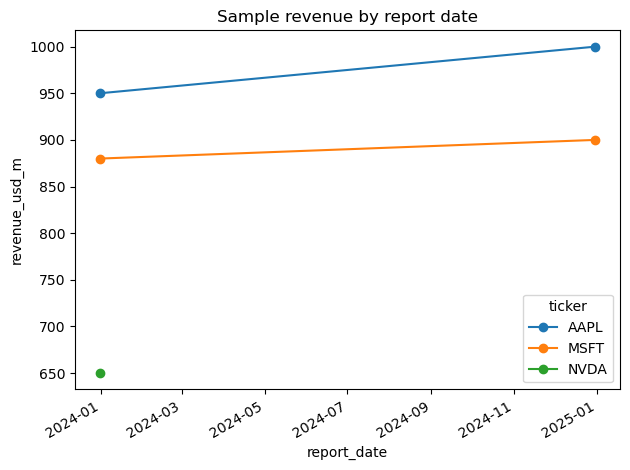

In [8]:
if not assets_dir.exists():
    raise FileNotFoundError("assets 폴더가 없습니다. 프로젝트 루트에 assets 폴더를 만든 뒤 다시 실행하세요.")

ax = line_chart_df.plot(kind="line", marker="o")
ax.set_title("Sample revenue by report date")
ax.set_xlabel("report_date")
ax.set_ylabel("revenue_usd_m")

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(chart_output_path, dpi=150)

print("saved_chart_path:", chart_output_path)
print("saved_chart_exists:", chart_output_path.exists())
plt.show()

latest_report_date: 2024-12-31
latest_operating_income_row_count: 3
latest_operating_income_order: ['MSFT', 'AAPL', 'NVDA']


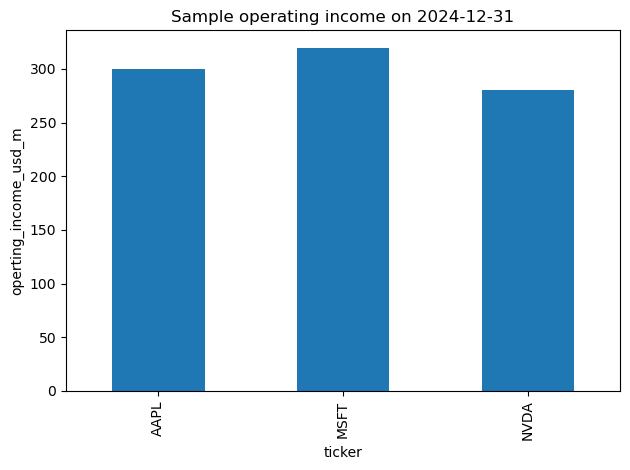

,ticker,operating_income_usd_m,unit,source_note
0,AAPL,300.0,USD million,class_sample
1,MSFT,320.0,USD million,class_sample
2,NVDA,280.0,USD million,class_sample


In [11]:
latest_report_date = chart_df["report_date"].max()
latest_operating_income_df = chart_df[chart_df["report_date"] == latest_report_date].sort_values("ticker")
latest_operating_income_order = (
    latest_operating_income_df
    .sort_values("operating_income_usd_m", ascending=False)["ticker"]
    .tolist()
)

print("latest_report_date:", latest_report_date.date())
print("latest_operating_income_row_count:", len(latest_operating_income_df))
print("latest_operating_income_order:", latest_operating_income_order)

ax = latest_operating_income_df.plot(
    kind="bar",
    x="ticker",
    y="operating_income_usd_m",
    legend=False,
)

ax.set_title("Sample operating income on 2024-12-31")
ax.set_xlabel('ticker')
ax.set_ylabel("operting_income_usd_m")
plt.tight_layout()
plt.show()

latest_operating_income_df[["ticker", "operating_income_usd_m", "unit", "source_note"]]

In [12]:
revenue_change_by_ticker = (
    line_chart_df.loc[pd.Timestamp("2024-12-31")]
    - line_chart_df.loc[pd.Timestamp("2023-12-31")]
)

interpretation_sentences = []

for ticker, change_value in revenue_change_by_ticker.items():
    if pd.isna(change_value):
        sentence = (
            f"2023-12-31부터 2024-12-31까지 {ticker}의 샘플 매출은 "
            "비교 기간 중 결측치가 있어 증감 문장을 확정하지 않는다."
        )
    elif change_value > 0:
        sentence = (
            f"2023-12-31부터 2024-12-31까지 {ticker}의 샘플 매출은 "
            f"{change_value:.0f} USD million 증가했다"
        )
    elif change_value < 0:
        sentence = (
            f"2023-12-31부터 2024-12-31까지 {ticker}의 샘플 매출은 "
            f"{change_value:.0f} USD million 감소했다"
        )
    else:
        sentence = (
            f"2023-12-31부터 2024-12-31까지 {ticker}의 샘플 매출은 변하지 않았다."
        )
    interpretation_sentences.append(sentence)

print("interpretation_sentence_count:", len(interpretation_sentences))

for sentence in interpretation_sentences:
    print("-", sentence)

interpretation_sentence_count: 3
- 2023-12-31부터 2024-12-31까지 AAPL의 샘플 매출은 50 USD million 증가했다
- 2023-12-31부터 2024-12-31까지 MSFT의 샘플 매출은 20 USD million 증가했다
- 2023-12-31부터 2024-12-31까지 NVDA의 샘플 매출은 비교 기간 중 결측치가 있어 증감 문장을 확정하지 않는다.
